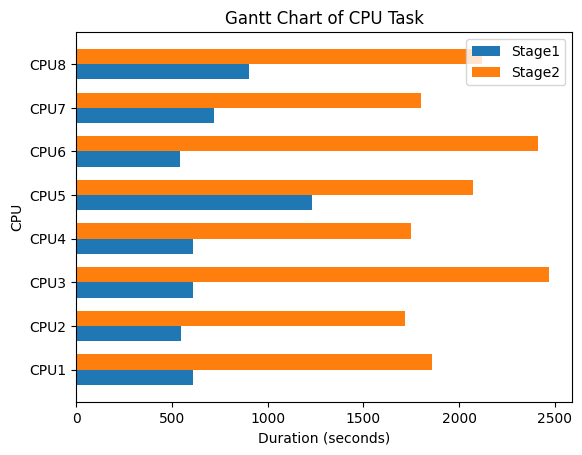

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Data
data = [
    ["CPU1", "Stage1", "00:10:08"],
    ["CPU2", "Stage1", "00:09:08"],
    ["CPU3", "Stage1", "00:10:10"],
    ["CPU4", "Stage1", "00:10:08"],
    ["CPU5", "Stage1", "00:20:30"],
    ["CPU6", "Stage1", "00:09:00"],
    ["CPU7", "Stage1", "00:12:00"],
    ["CPU8", "Stage1", "00:15:00"],
    ["CPU1", "Stage2", "00:30:56"],
    ["CPU2", "Stage2", "00:28:40"],
    ["CPU3", "Stage2", "00:41:09"],
    ["CPU4", "Stage2", "00:29:10"],
    ["CPU5", "Stage2", "00:34:32"],
    ["CPU6", "Stage2", "00:40:14"],
    ["CPU7", "Stage2", "00:30:00"],
    ["CPU8", "Stage2", "00:35:20"],
]

df = pd.DataFrame(data, columns=["CPU", "Task", "Duration"])

# Convert to seconds
df["Duration_sec"] = pd.to_timedelta(df["Duration"]).dt.total_seconds()

# Pivot
pivot = df.pivot(index="CPU", columns="Task", values="Duration_sec")

# Plot
y = np.arange(len(pivot.index))
bar_height = 0.35

plt.figure()

# Separate bars (NOT stacked)
plt.barh(y - bar_height/2, pivot["Stage1"], height=bar_height, label="Stage1")
plt.barh(y + bar_height/2, pivot["Stage2"], height=bar_height, label="Stage2")

plt.yticks(y, pivot.index)

plt.xlabel("Duration (seconds)")
plt.ylabel("CPU")
plt.title("Gantt Chart of CPU Task")

# Legend top-right
plt.legend(loc="upper right")

plt.show()

In [ ]:
import pandas as pd

data = []

with open(r"C:\Users\pky80\OneDrive\Desktop\college\PYTHON\template\project.txt", "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        
        if not line:
            continue
        line = line.replace(",", "")
        parts = line.split(" ")
        parts = [p for p in parts if p != ""]
        if len(parts) >= 4:
            row = parts[:4]
            cleaned_line = " ".join(row)
            
            data.append(cleaned_line)

with open("cleaned.txt", "w", encoding="utf-8") as f:
    for row in data:
        f.write(row + "\n")

print("Done")

Done ✅


In [ ]:
df = pd.DataFrame([row.split() for row in data],
                  columns=["ID", "Stage", "Value1", "Value2"])
df.to_csv("cleaned1.csv", index=False) 
print("done")


done


In [1]:
import pandas as pd
import plotly.express as px
import re

# ── 1. Load Data ───────────────────────────────────────────────
df = pd.read_csv(r"C:\Users\pky80\cleaned1.csv")
df.columns = ["CPU", "Stage", "Start", "End"]

df["Start"] = pd.to_numeric(df["Start"])
df["End"] = pd.to_numeric(df["End"])
df["Duration"] = df["End"] - df["Start"]

# ── 2. Grouping Logic ──────────────────────────────────────────
def get_base(name):
    s = str(name).lower().strip()
    s = re.sub(r'(_+part\d+)$|(_+\d+)$', '', s)
    return s

df["Base"] = df["Stage"].apply(get_base)

unique_bases = df["Base"].unique()
base_to_label = {base: f"Stage {i+1}" for i, base in enumerate(unique_bases)}
df["Display_Label"] = df["Base"].map(base_to_label)

# ── 3. CPU ANALYSIS (FIXED LOGIC) ──────────────────────────────

# Total active time per CPU
cpu_summary = df.groupby("CPU").agg(
    Total_Active_Time=("Duration", "sum"),
    First_Start=("Start", "min"),
    Last_End=("End", "max")
).reset_index()

# Total time window per CPU
cpu_summary["Total_Time_Window"] = (
    cpu_summary["Last_End"] - cpu_summary["First_Start"]
)

# Correct idle time
cpu_summary["Idle_Time"] = (
    cpu_summary["Total_Time_Window"] - cpu_summary["Total_Active_Time"]
)

print("\nCPU Performance Summary:")
print(cpu_summary[["CPU", "Total_Active_Time", "Idle_Time"]])

# ── 4. COLOR PALETTE ───────────────────────────────────────────
color_sequence = (
    px.colors.qualitative.Alphabet +
    px.colors.qualitative.Dark24
)

# ── 5. GANTT CHART ─────────────────────────────────────────────
fig = px.bar(
    df,
    x="Duration",
    y="CPU",
    base="Start",
    color="Display_Label",
    orientation="h",
    color_discrete_sequence=color_sequence,
    hover_data={
        "Display_Label": True,
        
        "Start": ":.2f",
        "End": ":.2f",
        "Duration": False
    },
    title="CPU Gantt Chart - Execution Timeline"
)

# ── 6. UI POLISH ───────────────────────────────────────────────
fig.update_yaxes(autorange="reversed", type="category")

fig.update_layout(
    xaxis_title="Time (seconds)",
    yaxis_title="CPU Number",
    legend_title="Stages",
    barmode="overlay",
    plot_bgcolor="white",
    bargap=0.2
)

fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor="LightGray")
fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor="LightGray")

# ── 7. SHOW + EXPORT ───────────────────────────────────────────
fig.show()
fig.write_html("cpu_gantt_dashboard.html")


CPU Performance Summary:
    CPU  Total_Active_Time  Idle_Time
0     1               4207       2669
1     2               4275       2574
2     3               4357       2501
3     4               4045       2793
4     5               6433        412
5     6               4762       2086
6     7               3926       2909
7     8               4751       2096
8     9               5193       1652
9    10               3798       3006
10   11               4896       1962
11   12               4749       2050
12   13               4237       2558
13   14               6489       2388
14   15               5404       1376
15   16               8890       1915
16   17               4010       2767
17   18               4706       2065
18   19               3966       2827
19   20               6009        894
20   21               4204       2582
21   22               3795       2991
22   23               4022       2825
23   24               3851       2930
24   25               57